In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

### Data Sources and view data

In [2]:
#data
from tensorflow.keras.datasets import cifar10

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


array([[[159, 102, 101],
        [150,  91,  95],
        [153,  95,  97],
        ...,
        [ 91,  71,  56],
        [ 74,  63,  55],
        [ 76,  58,  55]],

       [[142,  75,  68],
        [146,  72,  66],
        [155,  76,  65],
        ...,
        [127, 105,  71],
        [122, 111,  93],
        [ 86,  69,  61]],

       [[109,  67,  75],
        [ 99,  58,  60],
        [105,  59,  52],
        ...,
        [137, 112,  80],
        [163, 132, 105],
        [ 93,  72,  71]],

       ...,

       [[244, 129,  70],
        [240, 123,  65],
        [241, 122,  65],
        ...,
        [156,  42,  15],
        [179,  59,  26],
        [200,  73,  36]],

       [[246, 133,  74],
        [243, 128,  72],
        [243, 127,  70],
        ...,
        [162,  44,  14],
        [178,  56,  22],
        [192,  65,  27]],

       [[246, 139,  82],
        [243, 133,  78],
        [244, 132,  77],
        ...,
        [166,  47,  14],
        [173,  51,  17],
        [182,  57,  19]]], dtype=uint8)
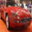

In [4]:
x_train[5]

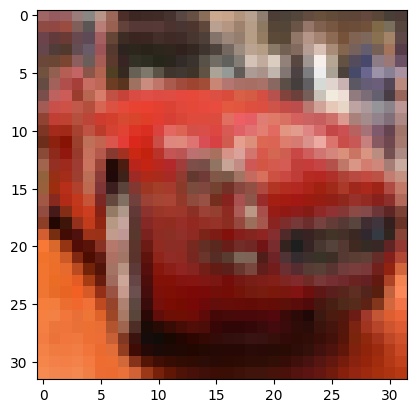

In [5]:
plt.imshow(x_train[5])

In [6]:
y_train[5]

array([1], dtype=uint8)

array([[[189, 203, 236],
        [188, 203, 236],
        [187, 202, 235],
        ...,
        [135, 158, 192],
        [134, 156, 190],
        [134, 156, 191]],

       [[178, 197, 232],
        [177, 196, 231],
        [177, 196, 231],
        ...,
        [137, 160, 194],
        [136, 159, 192],
        [136, 159, 193]],

       [[157, 182, 219],
        [158, 181, 218],
        [159, 183, 220],
        ...,
        [137, 160, 191],
        [135, 158, 190],
        [135, 158, 191]],

       ...,

       [[ 97, 118,  78],
        [ 95, 117,  75],
        [100, 121,  78],
        ...,
        [ 98, 119,  87],
        [ 98, 119,  84],
        [101, 123,  87]],

       [[125, 143, 120],
        [119, 138, 112],
        [110, 129, 101],
        ...,
        [109, 128,  98],
        [104, 124,  90],
        [101, 121,  85]],

       [[ 98, 115, 100],
        [114, 131, 117],
        [127, 143, 131],
        ...,
        [103, 121,  90],
        [103, 121,  87],
        [104, 122,  88]]], dtype=uint8)
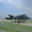

In [7]:
x_train[600]

In [8]:
y_train[600]

array([0], dtype=uint8)

### normalize the pixel vaues

In [9]:
x_train, x_test = x_train/255.0, x_test/255.0

### Exploring the data

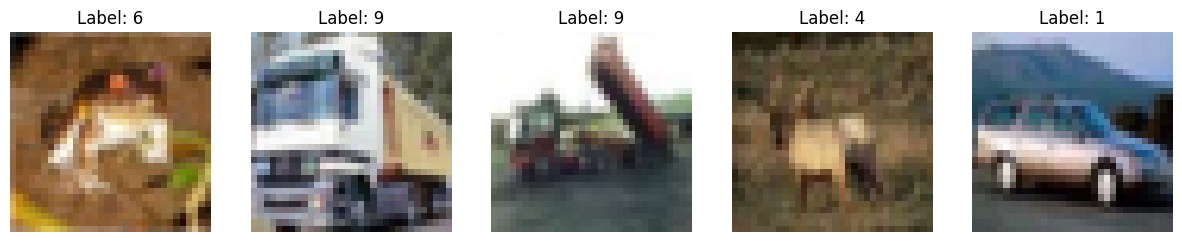

In [10]:
# Show a few sample images from the training set
fig, axes = plt.subplots(1, 5, figsize=(15, 15))
for i in range(5):
    axes[i].imshow(x_train[i])
    axes[i].set_title(f'Label: {y_train[i][0]}')
    axes[i].axis('off')
plt.show()

### Build CNN model

In [12]:
model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Convolutional Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten layer to convert 3D tensor into 1D vector
    layers.Flatten(),

    # Dense layer (Fully connected layer)
    layers.Dense(64, activation='relu'),

    # Output layer with softmax for multi-class classification
    layers.Dense(10, activation='softmax')

])

### Compile the model

In [13]:
model.compile(optimizer ='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### Train the model

In [14]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 90ms/step - accuracy: 0.3313 - loss: 1.7899 - val_accuracy: 0.5084 - val_loss: 1.3617
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.5527 - loss: 1.2491 - val_accuracy: 0.6131 - val_loss: 1.1005
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 85ms/step - accuracy: 0.6185 - loss: 1.0787 - val_accuracy: 0.6423 - val_loss: 1.0041
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 88ms/step - accuracy: 0.6638 - loss: 0.9638 - val_accuracy: 0.6543 - val_loss: 1.0027
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.6904 - loss: 0.8845 - val_accuracy: 0.6759 - val_loss: 0.9318
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.7170 - loss: 0.8131 - val_accuracy: 0.6815 - val_loss: 0.9230
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 87ms/step - accuracy: 0.7299 - loss: 0.7746 - val_accuracy: 0.6888 - val_loss: 0.8846
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.7439 - loss: 0.7258 - 

### Evaluate model

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7144 - loss: 0.8259
Test accuracy: 0.7142


### Plot Training and Validation Accuracy/Loss (Optional)

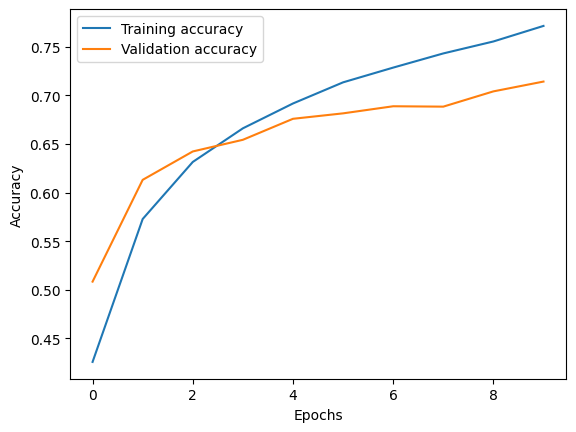

In [16]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


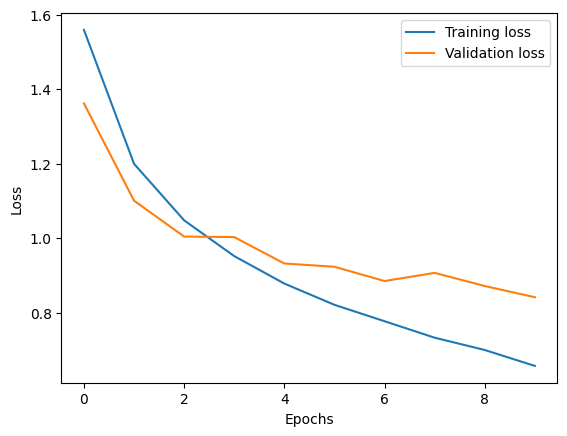

In [17]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### make prediction

In [18]:
# Predict the class for the first image in the test set
predictions = model.predict(x_test)

# Get the predicted class (the index of the highest probability)
predicted_class = predictions[0].argmax()

# Print the predicted class and actual class
print(f"Predicted class: {predicted_class}, Actual class: {y_test[0][0]}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Predicted class: 3, Actual class: 3
